# RFM Ideology Probe — Qwen3-VL

Probe the liberal-conservative ideology dimension from Qwen3-VL using the **Random Feature Model** (RFM) method. Unlike the per-head ridge regression in `vl_vision_probe.ipynb`, RFM operates on the full hidden state at each transformer layer, learning a nonlinear metric to find the most discriminative direction.

**Pipeline:**
1. Extract last-token hidden states across all layers for each politician prompt
2. Per layer: run RFM iterative metric learning → concept direction `u ∈ ℝ^D`
3. Evaluate val-set Pearson correlation per layer
4. Apply steering hooks during generation


In [3]:
%load_ext autoreload
%autoreload 2

import sys, os, json, pickle
from pathlib import Path

# Make rfm/ subpackage importable
RFM_DIR = str(Path("rfm").resolve())
if RFM_DIR not in sys.path:
    sys.path.insert(0, RFM_DIR)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split

from transformers import AutoModelForImageTextToText, AutoProcessor
import transformers

# RFM modules (from rfm/ subfolder)
import rfm as rfm_module                           # rfm/rfm.py
from direction_utils import train_rfm_probe_on_concept  # rfm/direction_utils.py

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

ROOT        = Path(".")
HS_PATH     = ROOT / "data" / "HS116_members.csv"
CUR_PATH    = ROOT / "data" / "legislators-current.json"
HIST_PATH   = ROOT / "data" / "legislators-historical.json"
MODEL_PATH  = "/home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct"
RESULTS_DIR = ROOT / "results"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("RFM path:", RFM_DIR)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda
RFM path: /project/jevans/tzhang3/dotty-project/linear-political-llm/rfm


In [4]:
# ── Load model & processor ────────────────────────────────────────────────────
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_PATH,
    dtype="auto",
    device_map="auto",
)
processor = AutoProcessor.from_pretrained(MODEL_PATH)
transformers.logging.set_verbosity_error()
print("Loaded:", MODEL_PATH)

# ── Discover layer structure ──────────────────────────────────────────────────
# Qwen3-VL uses model.model.layers for the transformer blocks.
# Walk named_modules to find the right path.
def find_transformer_layers(model):
    """Return the ModuleList of transformer decoder blocks."""
    for name, module in model.named_modules():
        if hasattr(module, "__len__") and name.endswith(".layers"):
            if len(module) > 0:
                return name, module
    raise RuntimeError("Could not find transformer layers in model.")

layer_path, transformer_layers = find_transformer_layers(model)
NUM_LAYERS  = len(transformer_layers)
HIDDEN_SIZE = model.config.text_config.hidden_size
print(f"Layer path  : {layer_path}")
print(f"Num layers  : {NUM_LAYERS}")
print(f"Hidden size : {HIDDEN_SIZE}")


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Loaded: /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
Layer path  : model.language_model.layers
Num layers  : 36
Hidden size : 4096


In [5]:
# ── Load politician data ───────────────────────────────────────────────────────
def _load_name_map(paths):
    by_bg = {}
    for p in paths:
        with open(p) as f:
            data = json.load(f)
        for person in data:
            bg = person.get("id", {}).get("bioguide")
            if not bg:
                continue
            name = person.get("name", {}).get("official_full")
            if not name:
                nm = person.get("name", {})
                name = " ".join(x for x in [nm.get("first", ""), nm.get("last", "")] if x).strip()
            by_bg[bg] = name
    return by_bg

name_map = _load_name_map([CUR_PATH, HIST_PATH])

df = pd.read_csv(HS_PATH)
df = df[pd.notnull(df["nominate_dim1"])].copy()
df["bioguide"] = df["bioguide_id"].astype(str).str.strip().str.upper()
df["name"]     = df["bioguide"].map(name_map).fillna(df["bioname"])
df = df.reset_index(drop=True)

labels = df["nominate_dim1"].astype(float).values
print(f"Rows: {len(df)}")
print(f"DW-NOMINATE range: [{labels.min():.3f}, {labels.max():.3f}]")
df[["bioguide", "name", "party_code", "nominate_dim1"]].head()


Rows: 552
DW-NOMINATE range: [-0.797, 0.891]


,bioguide,name,party_code,nominate_dim1
0,NaN,"TRUMP, Donald John",200,0.403
1,R000575,Mike Rogers,200,0.377
2,S001185,Terri A. Sewell,100,-0.398
3,R000591,Martha Roby,200,0.362
4,B001274,Mo Brooks,200,0.652


In [6]:
# ── Build text prompts ────────────────────────────────────────────────────────
# Each prompt conditions on the politician's name so the model can draw on
# its parametric knowledge of their ideology.  No image is used here so the
# learned direction reflects the textual (name-based) ideology signal.

def build_text_prompt(name: str) -> dict:
    messages = [{
        "role": "user",
        "content": [{"type": "text", "text": f"What would {name} say in a policy interview?"}],
    }]
    return processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )

prompts = [build_text_prompt(name) for name in df["name"].values]
print(f"Prompts: {len(prompts)}")
print("Sample:", df["name"].iloc[0], "→", processor.tokenizer.decode(prompts[0]["input_ids"][0][-10:]))


Prompts: 552
Sample: TRUMP, Donald John →  in a policy interview?<|im_end|>
<|im_start|>assistant



## Extract Layer-wise Hidden States

Run each tokenized prompt through the model with `output_hidden_states=True` and record the **last-token** representation at every transformer layer.
Result: `layer_reps[L]` is a `(N, D)` float32 tensor on CPU.


In [7]:
FEAT_CACHE = RESULTS_DIR / MODEL_PATH.split("/")[-1].lower() / "rfm_ideology_hidden_states.pkl"
FEAT_CACHE.parent.mkdir(parents=True, exist_ok=True)

if FEAT_CACHE.exists():
    print("Loading cached hidden states from", FEAT_CACHE)
    with open(FEAT_CACHE, "rb") as f:
        layer_reps, cached_labels = pickle.load(f)
    print(f"Loaded: {len(layer_reps)} layers × {layer_reps[0].shape[0]} samples × {layer_reps[0].shape[1]} dims")
else:
    print("Extracting hidden states (one forward pass per sample)...")
    # layer_reps[i] will be a list of (1, D) tensors, one per prompt
    layer_reps_lists = [[] for _ in range(NUM_LAYERS)]

    model.eval()
    with torch.no_grad():
        for enc in tqdm(prompts, total=len(prompts)):
            inputs = {k: v.to(device) for k, v in enc.items() if isinstance(v, torch.Tensor)}
            out = model(**inputs, output_hidden_states=True)
            # out.hidden_states: tuple of (1, seq_len, D), index 0 = embedding
            for layer_idx, hs in enumerate(out.hidden_states[1:]):
                layer_reps_lists[layer_idx].append(
                    hs[:, -1, :].squeeze(0).to(dtype=torch.float32).cpu()
                )

    # Stack into (N, D) tensors per layer
    layer_reps = [torch.stack(reps, dim=0) for reps in layer_reps_lists]
    cached_labels = labels.copy()

    with open(FEAT_CACHE, "wb") as f:
        pickle.dump((layer_reps, cached_labels), f)
    print("Saved to", FEAT_CACHE)

print(f"Shape per layer: {layer_reps[0].shape}  (N={layer_reps[0].shape[0]}, D={layer_reps[0].shape[1]})")


Loading cached hidden states from results/qwen3-vl-8b-instruct/rfm_ideology_hidden_states.pkl
Loaded: 36 layers × 552 samples × 4096 dims
Shape per layer: torch.Size([552, 4096])  (N=552, D=4096)


## RFM Probe: Per-layer Ideology Direction

For each layer:
1. 80/20 train/val split (stratified by party sign)
2. Grid-search over bandwidths `{1, 10, 100}` and normalization on/off
3. Run `rfm_module.rfm()` — iterative kernel metric learning
4. Keep the direction `u ∈ ℝ^D` that achieves best val Pearson `r`


In [8]:
DIRECTIONS_CACHE = FEAT_CACHE.parent / "rfm_ideology_directions.pkl"

if DIRECTIONS_CACHE.exists():
    print("Loading cached RFM directions from", DIRECTIONS_CACHE)
    with open(DIRECTIONS_CACHE, "rb") as f:
        directions, val_correlations = pickle.load(f)
else:
    N = layer_reps[0].shape[0]
    y_all = torch.tensor(cached_labels, dtype=torch.float32).reshape(-1, 1)

    # Reproducible 80/20 split (fixed indices, not stratified, to match rfm convention)
    rng = np.random.default_rng(SEED)
    idx = rng.permutation(N)
    n_train = int(0.8 * N)
    train_idx = torch.from_numpy(idx[:n_train])
    val_idx   = torch.from_numpy(idx[n_train:])

    y_train = y_all[train_idx].cuda()
    y_val   = y_all[val_idx].cuda()

    directions      = {}   # layer → (D,) CPU tensor, unit concept vector
    val_correlations = {}  # layer → float, best val Pearson r

    for layer_idx in tqdm(range(NUM_LAYERS), desc="RFM per layer"):
        X_all = layer_reps[layer_idx]  # (N, D) CPU float32

        X_train = X_all[train_idx].cuda()
        X_val   = X_all[val_idx].cuda()

        # train_rfm_probe_on_concept does the bandwidth / norm grid search internally
        best_u = train_rfm_probe_on_concept(
            train_X=X_train,
            train_y=y_train,
            val_X=X_val,
            val_y=y_val,
            hyperparams={},        # uses internal defaults (bws=[1,10,100], reg=1e-3, iters=10)
        )

        if best_u is None:
            directions[layer_idx]       = None
            val_correlations[layer_idx] = 0.0
            continue

        # Compute actual val Pearson with the chosen direction
        u_cpu = best_u.squeeze().cpu().float()
        proj_val = (X_val @ best_u).squeeze().cpu().float()
        y_val_cpu = y_val.squeeze().cpu().float()
        r = float(pearsonr(y_val_cpu.numpy(), proj_val.numpy()).statistic)

        # Sign convention: align with DW-NOMINATE (positive = conservative)
        if r < 0:
            u_cpu = -u_cpu
            r = -r

        directions[layer_idx]       = u_cpu
        val_correlations[layer_idx] = r

        # Free GPU memory each iteration
        del X_train, X_val
        torch.cuda.empty_cache()

    with open(DIRECTIONS_CACHE, "wb") as f:
        pickle.dump((directions, val_correlations), f)
    print("Saved to", DIRECTIONS_CACHE)

print("\nTop 5 layers by val Pearson r:")
top5 = sorted(val_correlations.items(), key=lambda x: x[1], reverse=True)[:5]
for li, r in top5:
    print(f"  Layer {li:3d}: r = {r:.4f}")


Loading cached RFM directions from results/qwen3-vl-8b-instruct/rfm_ideology_directions.pkl

Top 5 layers by val Pearson r:
  Layer  21: r = 0.9051
  Layer  17: r = 0.8962
  Layer  19: r = 0.8920
  Layer  20: r = 0.8911
  Layer  26: r = 0.8896


Best layer: 21  |  val Pearson r = 0.9051


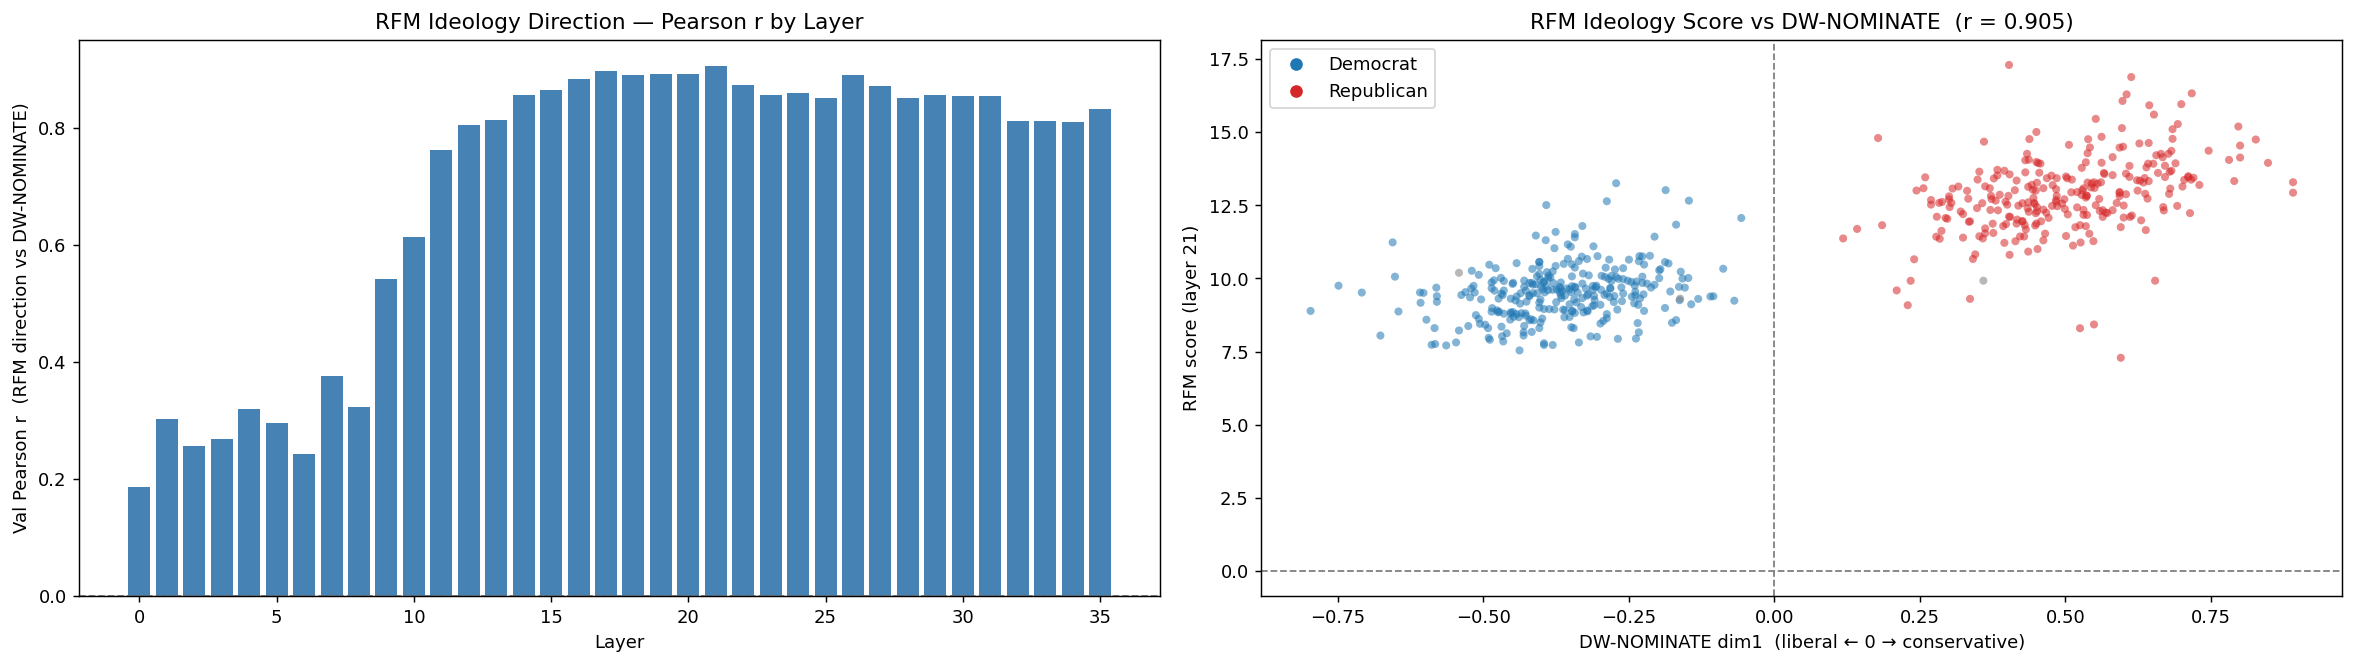

Spearman rho: 0.8029


In [9]:
# ── Evaluation: per-layer Pearson r + DW-NOMINATE scatter for best layer ──────

layer_indices = sorted(val_correlations.keys())
r_values      = [val_correlations[li] for li in layer_indices]
best_layer    = max(val_correlations, key=val_correlations.get)
best_r        = val_correlations[best_layer]
best_u        = directions[best_layer]

print(f"Best layer: {best_layer}  |  val Pearson r = {best_r:.4f}")

# ── Panel 1: per-layer bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5), dpi=130, constrained_layout=True)

axes[0].bar(layer_indices, r_values, color="steelblue", edgecolor="none")
axes[0].axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Val Pearson r  (RFM direction vs DW-NOMINATE)")
axes[0].set_title("RFM Ideology Direction — Pearson r by Layer")

# ── Panel 2: scatter best layer ───────────────────────────────────────────────
X_all    = layer_reps[best_layer]          # (N, D) CPU
scores   = (X_all @ best_u).numpy()       # (N,)
dw       = cached_labels

party_colors = {100: "#1f77b4", 200: "#d62728"}  # Dem / Rep
colors = [party_colors.get(int(pc), "#7f7f7f") for pc in df["party_code"].values]

axes[1].scatter(dw, scores, c=colors, alpha=0.55, s=20, edgecolors="none")
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="Democrat",
           markerfacecolor="#1f77b4", markersize=8),
    Line2D([0], [0], marker="o", color="w", label="Republican",
           markerfacecolor="#d62728", markersize=8),
]
axes[1].legend(handles=legend_elements, loc="best")
axes[1].axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("DW-NOMINATE dim1  (liberal ← 0 → conservative)")
axes[1].set_ylabel(f"RFM score (layer {best_layer})")
axes[1].set_title(f"RFM Ideology Score vs DW-NOMINATE  (r = {best_r:.3f})")

plt.show()

# ── Global Spearman rho ───────────────────────────────────────────────────────
rho = spearmanr(dw, scores).statistic
print(f"Spearman rho: {rho:.4f}")


## Steering with the RFM Concept Vector

Install forward hooks on the top-K layers (by val r) that shift each layer's hidden state by `α * u_layer`.
- `α > 0` → conservative direction (higher DW-NOMINATE)
- `α < 0` → liberal direction


In [16]:
TOP_K_LAYERS   = 8    # How many layers to steer simultaneously
ALPHA_LIBERAL  = -5
ALPHA_CONSERV  =  5
MAX_NEW_TOKENS = 150

# Select top-K layers sorted by val_r
sorted_layers = sorted(val_correlations.items(), key=lambda x: x[1], reverse=True)
steer_layers  = [li for li, _ in sorted_layers[:TOP_K_LAYERS] if directions[li] is not None]
print(f"Steering on layers: {steer_layers}")
print(f"Val r for each    : {[round(val_correlations[li], 3) for li in steer_layers]}")

# ── Hook helpers ──────────────────────────────────────────────────────────────
def install_hooks(model, layer_path_base, steer_layers, directions, alpha):
    """
    Register forward hooks that add `alpha * u` to each selected layer's output.
    layer_path_base: e.g. 'model.model.layers' or 'model.language_model.layers'
    Returns list of hook handles.
    """
    hooks = []
    layer_module = model
    for attr in layer_path_base.split("."):
        layer_module = getattr(layer_module, attr)  # walks down to the ModuleList

    for li in steer_layers:
        u = directions[li].to(device=device, dtype=model.dtype)  # (D,)

        def _hook(module, input, output, _u=u, _alpha=alpha):
            h = output[0] if isinstance(output, tuple) else output
            h = h + _alpha * _u.reshape(1, 1, -1)
            if isinstance(output, tuple):
                return (h,) + output[1:]
            return h

        handle = layer_module[li].register_forward_hook(_hook)
        hooks.append(handle)
    return hooks


def remove_hooks(hooks):
    for h in hooks:
        h.remove()


def generate_with_steering(model, processor, prompt_text: str, alpha: float, max_new_tokens: int = 150) -> str:
    messages = [{"role": "user", "content": [{"type": "text", "text": prompt_text}]}]
    enc = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in enc.items() if isinstance(v, torch.Tensor)}

    hooks = install_hooks(model, layer_path, steer_layers, directions, alpha)
    try:
        with torch.no_grad():
            out_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=processor.tokenizer.eos_token_id,
            )
    finally:
        remove_hooks(hooks)

    # Decode only the newly generated tokens
    n_input = inputs["input_ids"].shape[1]
    return processor.tokenizer.decode(out_ids[0, n_input:], skip_special_tokens=True)


# ── Generate ──────────────────────────────────────────────────────────────────
policy_topics = [
    "As a US politician, generate a statement on immigration policy?",
    "As a US politician, generate a statement on gun control?",
    "As a US politician, generate a statement on abortion policy?",
    "As a US politician, generate a statement on climate change?",
]

for topic in policy_topics:
    liberal_resp    = generate_with_steering(model, processor, topic, ALPHA_LIBERAL,  MAX_NEW_TOKENS)
    conserv_resp    = generate_with_steering(model, processor, topic, ALPHA_CONSERV,  MAX_NEW_TOKENS)
    unsteered_resp  = generate_with_steering(model, processor, topic, 0.0,            MAX_NEW_TOKENS)

    print("=" * 100)
    print(f"Topic: {topic}")
    print(f"\n[No steering]")
    print(unsteered_resp)
    print(f"\n[Liberal   α={ALPHA_LIBERAL}]")
    print(liberal_resp)
    print(f"\n[Conservative α={ALPHA_CONSERV}]")
    print(conserv_resp)
    print()


Steering on layers: [21, 17, 19, 20, 26, 18, 16, 22]
Val r for each    : [0.905, 0.896, 0.892, 0.891, 0.89, 0.889, 0.883, 0.873]
Topic: As a US politician, generate a statement on immigration policy?

[No steering]
As a U.S. politician committed to national security, economic prosperity, and the rule of law, I believe our immigration policy must balance compassion with responsibility. We must secure our borders—not as a barrier, but as a safeguard—for the safety of our citizens and the integrity of our institutions. At the same time, we must modernize our system to reflect the realities of the 21st century: streamlining legal pathways for skilled workers, family reunification, and refugees fleeing persecution; enforcing immigration laws fairly and consistently; and investing in border infrastructure and technology to prevent exploitation and human trafficking.

We must also address the root causes of migration—economic inequality, violence, and instability—through diplomacy and develop

### Analysis of AI Steering on Political Topics



| Topic              | Liberal Steering (α=−5)                                                                                                                       | Conservative Steering (α=5)                                                                                                                  |
| ------------------ | --------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------- |
| **Immigration**    | "...expanding legal pathways for Dreamers, asylum seekers... not just as workers, but as neighbors, parents, and innovators."                 | "Our immigration system must prioritize national security... and ensure that legal immigration remains the primary pathway..."               |
| **Gun Control**    | "...pass legislation that makes our streets safer, our schools secure... because every life matters, and every community deserves to thrive." | "I oppose legislation that would ban firearms outright or impose sweeping restrictions \[on lawful citizens]."                               |
| **Abortion**       | "...a deeply personal, often life-altering decision that should be made with dignity... not by politicians imposing their beliefs..."         | "...life begins at conception, and therefore, abortion should be prohibited except in cases where the mother’s life is in immediate danger." |
| **Climate Change** | "...not just an environmental crisis, it’s a moral, economic, and existential emergency... a \[green] revolution."                            | "...policy must prioritize American energy production, including responsible development of domestic oil, natural gas, and coal..."          |